In [51]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
import joblib

subm = pd.read_csv('../data/sample_submission.csv')
X_tr = pd.read_csv('../data/X_tr_new.csv')
X_test = pd.read_csv('../data/X_test_new.csv')
y = pd.read_csv('../data/y.csv')
y = np.ravel(y)

X_train, X_val, y_train, y_val = train_test_split(X_tr, y, test_size=0.2, random_state=42)

In [54]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier

from sklearn.metrics import roc_auc_score, accuracy_score, recall_score

models = {
    'cb' : CatBoostClassifier(random_state=42, verbose=0),
    'xgb' : XGBClassifier(random_state=42, eval_metric = 'logloss'),
    'lgb' : LGBMClassifier(random_state=42, verbose=-1), 
    'gb' : GradientBoostingClassifier(random_state=42),
    'ada' : AdaBoostClassifier(random_state=42)
}

res = {}

for name, model in models.items():
    print(name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    res[name] = {'acc' : accuracy_score(y_val, y_pred), 'recall' : recall_score(y_val, y_pred), 'roc-auc' : roc_auc_score(y_val, y_pred_proba)} 
    print(res[name])

cb
{'acc': 0.8869603174603174, 'recall': 0.8659543553760012, 'roc-auc': 0.9550077002911269}
xgb
{'acc': 0.8865079365079365, 'recall': 0.8658480402579913, 'roc-auc': 0.9544594578811731}
lgb
{'acc': 0.8865555555555555, 'recall': 0.8668757530654192, 'roc-auc': 0.9545201163688076}
gb
{'acc': 0.8857936507936508, 'recall': 0.8630484088170671, 'roc-auc': 0.9534475548957428}
ada
{'acc': 0.8833492063492063, 'recall': 0.8609575448295415, 'roc-auc': 0.9515433618383293}


In [5]:
preds = models['cb'].predict_proba(X_test)[:, 1]
subm['Heart Disease'] = preds
subm.to_csv('../data/subm/cb_fe.csv', index=False)

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.metrics import make_scorer

auc_scorer = make_scorer(roc_auc_score, needs_proba=True, greater_is_better=True)

base_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'od_type': 'Iter',
    'od_wait': 50,
    'task_type': 'CPU',                   
    'verbose': True,
    'random_seed': 42
}



param_grid = {
    'iterations': [1500, 2000],        
    'learning_rate': [0.03, 0.05],     
    'depth': [6, 8],                     
    'l2_leaf_reg': [3, 5, 7],            
    'border_count': [128],                
}

catboost = CatBoostClassifier(**base_params)

grid_search = GridSearchCV(
    estimator=catboost,
    param_grid=param_grid,
    scoring=auc_scorer,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    verbose=False,
    n_jobs=1, 
    return_train_score=True
)

X_full = np.vstack([X_train, X_test])
y_full = np.hstack([y_train, y_val])


grid_search.fit(X_full, y_full)


cb_fe_2 = CatBoostClassifier(
    **base_params,
    **grid_search.best_params_
)

cb_fe_2.fit(
    X_train, y_train,
    eval_set=(X_test, y_val),
    use_best_model=True,
    verbose=100
)

val_pred = cb_fe_2.predict_proba(X_test)[:, 1]
val_auc = roc_auc_score(y_val, val_pred)
print(f"auc: {val_auc}")


joblib.dump(cb_fe_2, 'models/catboost_fe.pkl')

In [ ]:
cb_new = joblib.load('models/catboost_fe.pkl')
preds = cb_new.predict_proba(X_test)[:, 1]
subm['Heart Disease'] = preds
subm.to_csv('../data/subm/cb-fe_2.csv', index=False)

катбуст
1) на валидации: 0.9551941147204536, перебор параметров не дал прироста
2) кагл 0.95337

In [ ]:
from flaml import AutoML


best = {}
best_configs = {}

models = ['catboost', 'xgboost', 'lgbm', 'histgb']
for model in models:  
    print(model)
    automl = AutoML()
    
    automl.fit(
        X_train=X_train, 
        y_train=y_train,
        time_budget=1000,
        task='classification',
        estimator_list=[model],
        metric = 'roc_auc',
        log_training_metric=True,
        verbose=2
    )
    
        
    best[model] = automl.model
    best_configs[model] = automl.best_config
    

joblib.dump(best, 'models/best_boostings.pkl')


In [8]:
m = joblib.load('models/best_boostings.pkl')

cb = m['catboost']
xgb = m['xgboost']
lgb = m['lgbm']
histgb= m['histgb']


for n, m in m.items():
    pr = m.predict_proba(X_test)[:, 1]
    print(n, roc_auc_score(y_val, pr))
    
    pr_test = m.predict_proba(X_test)[:, 1]
    
    subm['Heart Disease'] = pr_test
    subm.to_csv(f'../data/subm/{n}_automl.csv', index=False)

catboost 0.9541500183392712
xgboost 0.9551289999455883
lgbm 0.9552019704709245
histgb 0.9547713698410234


немного улучшились модели помимо катбуста,
кагл:
1) lgb 0.95531
2) xgb 0.95536
3) histgb 0.95293
4) cb 0.95228

cb 0.9551941147204536
histgb 0.9547713698410234
xgb 0.9551289999455883
lgb 0.9552019704709245


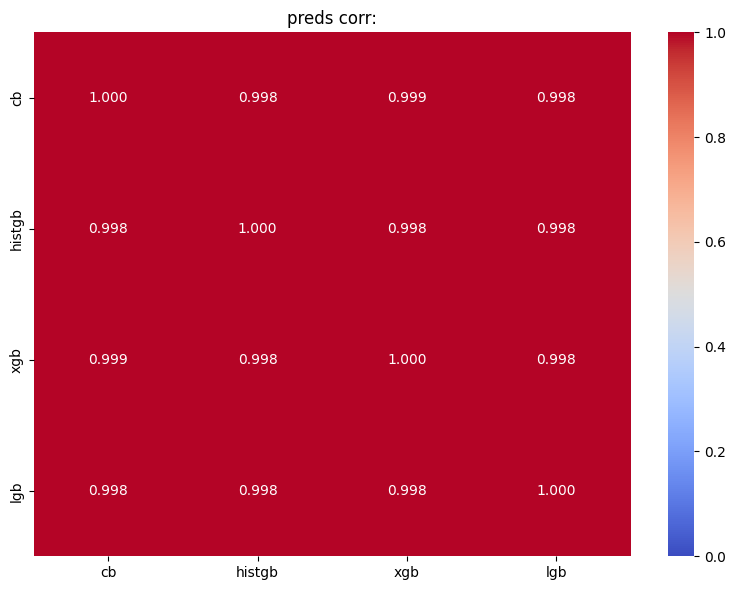

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

cb_fe_2 = joblib.load('models/catboost_fe.pkl')
predictions = {}

predictions['cb'] = cb_fe_2.predict_proba(X_test)[:, 1]
predictions['histgb'] = histgb.predict_proba(X_test)[:, 1]
predictions['xgb'] = xgb.predict_proba(X_test)[:, 1]
predictions['lgb'] = lgb.predict_proba(X_test)[:, 1]

pred_df = pd.DataFrame(predictions)

for name, preds in predictions.items():
    print(name, roc_auc_score(y_val, preds))
    
corr_matrix = pred_df.corr(method='spearman')


plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', 
            center=0.5, vmin=0, vmax=1, fmt='.3f')
plt.title('preds corr:')
plt.tight_layout()
plt.show()

In [67]:

ens = (cb_new.predict_proba(X_test)[:, 1] + lgb.predict_proba(X_test)[:, 1] + xgb.predict_proba(X_test)[:, 1]) / 3
subm['Heart Disease'] = ens
subm.to_csv('../data/subm/ens.csv', index=False)

простое усреднение дало 0.95343 на кагл

In [68]:
cb_preds = cb_new.predict_proba(X_test)[:, 1]
lgb_preds = lgb.predict_proba(X_test)[:, 1]
xgb_preds = xgb.predict_proba(X_test)[:, 1]
hist_preds = histgb.predict_proba(X_test)[:, 1]


best_score = 0
best_weights = [1/4, 1/4, 1/4, 1/4]


for w1 in np.arange(0, 1.01, 0.05):
    for w2 in np.arange(0, 1.01 - w1, 0.05):
        for w3 in np.arange(0, 1 - w1 - w2, 0.05):
            w4 = 1 - w1 - w2 - w3


            ensemble = (w1 * cb_preds + 
                        w2 * lgb_preds + 
                        w3 * xgb_preds + 
                        w4 * hist_preds)
            score = roc_auc_score(y_val, ensemble)

            if score > best_score:
                best_score = score
                best_weights = (w1, w2, w3, w4)
                print(f"w: cb={w1}, lgb={w2}, xgb={w3}, hist={w4}")
                print(f"auc: {score}")

final_ens = (best_weights[0] * cb_new.predict_proba(X_test)[:, 1] + 
                  best_weights[1] * lgb.predict_proba(X_test)[:, 1] + 
                  best_weights[2] * xgb.predict_proba(X_test)[:, 1] + 
                  best_weights[3] * histgb.predict_proba(X_test)[:, 1])

best_weights

w: cb=0.0, lgb=0.0, xgb=0.0, hist=1.0
auc: 0.9547713698410234
w: cb=0.0, lgb=0.0, xgb=0.05, hist=0.95
auc: 0.9548127658074081
w: cb=0.0, lgb=0.0, xgb=0.1, hist=0.9
auc: 0.9548514011426982
w: cb=0.0, lgb=0.0, xgb=0.15000000000000002, hist=0.85
auc: 0.954887736376605
w: cb=0.0, lgb=0.0, xgb=0.2, hist=0.8
auc: 0.954921638037022
w: cb=0.0, lgb=0.0, xgb=0.25, hist=0.75
auc: 0.954952829245743
w: cb=0.0, lgb=0.0, xgb=0.30000000000000004, hist=0.7
auc: 0.9549821956564231
w: cb=0.0, lgb=0.0, xgb=0.35000000000000003, hist=0.6499999999999999
auc: 0.9550088421908501
w: cb=0.0, lgb=0.0, xgb=0.4, hist=0.6
auc: 0.9550327461791428
w: cb=0.0, lgb=0.0, xgb=0.45, hist=0.55
auc: 0.9550545877177239
w: cb=0.0, lgb=0.0, xgb=0.5, hist=0.5
auc: 0.9550736337288767
w: cb=0.0, lgb=0.0, xgb=0.55, hist=0.44999999999999996
auc: 0.9550900278734182
w: cb=0.0, lgb=0.0, xgb=0.6000000000000001, hist=0.3999999999999999
auc: 0.9551041509544016
w: cb=0.0, lgb=0.0, xgb=0.65, hist=0.35
auc: 0.9551157839145523
w: cb=0.0, lgb=0

(np.float64(0.45),
 np.float64(0.45),
 np.float64(0.1),
 np.float64(2.7755575615628914e-17))

In [69]:
subm['Heart Disease'] = final_ens
subm.to_csv('../data/subm/final_ens.csv', index=False)

0.95344 кагл

добавление еще моделей

In [49]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, interaction_only=True)
X_train_lr = poly.fit_transform(X_train)
X_test_lr = poly.transform(X_test)


катбуст
1) на валидации: 0.9551941147204536, перебор параметров не дал прироста
2) кагл 0.95337

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import roc_auc_score, make_scorer
auc_scorer = make_scorer(roc_auc_score, needs_proba=True, greater_is_better=True)

poly = PolynomialFeatures(degree=2, interaction_only=True)
X_train_lr = poly.fit_transform(X_train)
X_test_lr = poly.transform(X_test)


lr = LogisticRegression(
    random_state=42,
    max_iter=2000,
    solver='liblinear' 
)

param_grid = {
    'C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0], 
    'penalty': ['l1', 'l2']
}


grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring=auc_scorer,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    verbose=2,
    n_jobs=2
)


grid_search.fit(X_train_lr, y_train)

joblib.dump(grid_search.best_estimator_, 'models/lr_fe.pkl')

lr_pred_val = grid_search.best_estimator_.predict_proba(X_test_lr)[:, 1]
lr_best_auc = roc_auc_score(y_val, lr_pred_val)

print(f"auc {lr_best_auc}")


In [4]:
import joblib
joblib.dump(grid_search.best_estimator_, 'models/lr_fe.pkl')

lr_fe = grid_search.best_estimator_
lr_pred_val = lr_fe.predict_proba(X_test_lr)[:, 1]
lr_best_auc = roc_auc_score(y_val, lr_pred_val)

print(f"auc {lr_best_auc}")

auc 0.9529075974356875


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV


X_sample, y_sample = resample(
    X_train, y_train, 
    n_samples=150000, 
    random_state=42,
    stratify=y_train
)


rf_params_optimized = {
    'n_estimators': [300, 500],        
    'max_depth': [15, 20, None],        
    'min_samples_split': [50, 100], 
    'min_samples_leaf': [20, 50],       
    'max_features': ['sqrt', 0.5],     
    'bootstrap': [True]               
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42, 
        n_jobs=4,                 
        verbose=0,         
    ),
    rf_params_optimized,
    n_iter=20,                       
    cv=3,
    scoring='roc_auc',
    verbose=2,
    random_state=42,
    n_jobs=1                      
)


rf_search.fit(X_sample, y_sample)


rf_fe = RandomForestClassifier(
    **rf_search.best_params_,
    random_state=42,
    n_jobs=4,  
    verbose=1
)

rf_fe.fit(X_train, y_train)

rf_pred_val = rf_fe.predict_proba(X_test)[:, 1]
rf_final_auc = roc_auc_score(y_val, rf_pred_val)
print(f"auc {rf_final_auc}")

joblib.dump(rf_fe, 'models/rf_fe.pkl')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END bootstrap=True, max_depth=20, max_features=0.5, min_samples_leaf=20, min_samples_split=100, n_estimators=500; total time=  38.4s
[CV] END bootstrap=True, max_depth=20, max_features=0.5, min_samples_leaf=20, min_samples_split=100, n_estimators=500; total time=  45.8s
[CV] END bootstrap=True, max_depth=20, max_features=0.5, min_samples_leaf=20, min_samples_split=100, n_estimators=500; total time=  45.7s
[CV] END bootstrap=True, max_depth=None, max_features=0.5, min_samples_leaf=20, min_samples_split=50, n_estimators=300; total time=  29.0s
[CV] END bootstrap=True, max_depth=None, max_features=0.5, min_samples_leaf=20, min_samples_split=50, n_estimators=300; total time=  28.4s
[CV] END bootstrap=True, max_depth=None, max_features=0.5, min_samples_leaf=20, min_samples_split=50, n_estimators=300; total time=  28.6s
[CV] END bootstrap=True, max_depth=20, max_features=0.5, min_samples_leaf=20, min_samples_split=100, n_estim

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   33.5s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:  2.5min
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:  3.9min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    2.2s finished


auc 0.9517105308124963


['rf_fe.pkl']

In [70]:
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier(n_estimators=500, n_jobs=-1, random_state=42)
et.fit(X_train, y_train)

roc_auc_score(y_val, et.predict_proba(X_test)[:, 1])

0.9441979922746672

In [82]:
from sklearn.ensemble import ExtraTreesClassifier

X_et, y_et = resample(X_train, y_train, n_samples=150000, random_state=42, stratify=y_train)

et_params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [15, 20, None],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 50],
    'max_features': ['sqrt', 'log2', 0.5],
    'bootstrap': [True, False]
}

et = ExtraTreesClassifier(random_state=42, n_jobs=-1)

et_search = RandomizedSearchCV(
    et,
    et_params,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    verbose=2,
    random_state=42,
    n_jobs=1  
)

et_search.fit(X_et, y_et)

et = ExtraTreesClassifier(**et_search.best_params_, random_state=42, n_jobs=-1)
et.fit(X_train, y_train)

print(roc_auc_score(y_val, et.predict_proba(X_test)[:, 1]))
joblib.dump(et,  'models/et.pkl')
subm['Heart Disease'] = et.predict_proba(X_test)[:, 1]
subm.to_csv('../data/subm/et.csv', index=False)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=20, min_samples_split=100, n_estimators=200; total time=   3.6s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=20, min_samples_split=100, n_estimators=200; total time=   3.5s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=20, min_samples_split=100, n_estimators=200; total time=   3.5s
[CV] END bootstrap=False, max_depth=15, max_features=sqrt, min_samples_leaf=50, min_samples_split=20, n_estimators=300; total time=   4.4s
[CV] END bootstrap=False, max_depth=15, max_features=sqrt, min_samples_leaf=50, min_samples_split=20, n_estimators=300; total time=   4.6s
[CV] END bootstrap=False, max_depth=15, max_features=sqrt, min_samples_leaf=50, min_samples_split=20, n_estimators=300; total time=   4.5s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=50, min_samples_sp

In [72]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm = LinearSVC(C=1.0, dual=False, max_iter=2000, random_state=42)
svm.fit(X_train, y_train)

svm_cal = CalibratedClassifierCV(svm, method='sigmoid')
svm_cal.fit(X_train, y_train)
roc_auc_score(y_val, svm_cal.predict_proba(X_test)[:, 1])

0.9525252821234564

In [81]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import RandomizedSearchCV

X_m, y_m = resample(X_train, y_train, n_samples=150000, random_state=42, stratify=y_train)

svm_params = {
    'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'max_iter': [1000, 2000, 3000]
}

svm_base = LinearSVC(random_state=42, loss='squared_hinge', dual=False)

svm_search = RandomizedSearchCV(
    svm_base,
    svm_params,
    n_iter=18,
    cv=3,
    scoring='roc_auc',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

svm_search.fit(X_m, y_m)


svm_best = LinearSVC(**svm_search.best_params_, random_state=42)
svm_best.fit(X_train, y_train)
svm_cal = CalibratedClassifierCV(svm_best, method='sigmoid', cv=3)

svm_cal.fit(X_train, y_train)
print(roc_auc_score(y_val, svm_cal.predict_proba(X_test)[:, 1]))

joblib.dump(svm_cal, 'models/svm.pkl')
subm['Heart Disease'] = svm_cal.predict_proba(X_test)[:, 1]
subm.to_csv('../data/subm/svm.csv', index=False)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
0.9525252553780914


In [71]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    batch_size=512, 
    early_stopping=True,
    max_iter=200,
    random_state=42
)
mlp.fit(X_train, y_train)
roc_auc_score(y_val,  mlp.predict_proba(X_test)[:, 1])

0.9529198328033431

In [83]:
from sklearn.neural_network import MLPClassifier

X_mlp, y_mlp = resample(X_train, y_train, n_samples=150000, random_state=42, stratify=y_train)

mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'batch_size': [256, 512],
    'max_iter': [200, 300]
}

mlp_base = MLPClassifier(random_state=42, early_stopping=True)

mlp_search = RandomizedSearchCV(
    mlp_base,
    mlp_params,
    n_iter=15,
    cv=3,
    scoring='roc_auc',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

mlp_search.fit(X_mlp, y_mlp)

mlp = MLPClassifier(**mlp_search.best_params_, random_state=42, early_stopping=True)
mlp.fit(X_train, y_train)

joblib.dump(svm_cal, 'models/mlp.pkl')
subm['Heart Disease'] = mlp.predict_proba(X_test)[:, 1]
subm.to_csv('../data/subm/mlp.csv', index=False)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


In [84]:
roc_auc_score(y_val,  mlp.predict_proba(X_test)[:, 1])

0.9529170309079708

перебор для mlp и svm вообще не дал прироста

In [85]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import RandomizedSearchCV

X_mlp, y_mlp = resample(X_train, y_train, n_samples=150000, random_state=42, stratify=y_train)


hidden_layer_options = [
    (8,), (12,), (16,), (24,),
    (12, 6), (16, 8), (24, 12),
    (16, 12, 8)
]

mlp_params = {
    'hidden_layer_sizes': hidden_layer_options,
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],  
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [256, 512]
}


mlp_search = RandomizedSearchCV(
    MLPClassifier(random_state=42, early_stopping=True, validation_fraction=0.1, n_iter_no_change=10, max_iter=300),
    mlp_params,
    n_iter=30,
    cv=3,
    scoring='roc_auc',
    verbose=2,
    random_state=42,
    n_jobs=-1
)


mlp_search.fit(X_mlp, y_mlp)

mlp_2 = mlp_search.best_estimator_
mlp_2.fit(X_train, y_train)

print(f"auc {roc_auc_score(y_val, mlp_2.predict_proba(X_test)[:, 1])}")


joblib.dump(mlp_2, 'models/mlp_2.pkl')

subm['Heart Disease'] = mlp_2.predict_proba(X_test)[:, 1]
subm.to_csv('../data/subm/mlp.csv', index=False)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
auc 0.9530294574692232


In [86]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.model_selection import RandomizedSearchCV

X_nb, y_nb = resample(X_train, y_train, n_samples=150000, random_state=42, stratify=y_train)


gnb_params = {
    'var_smoothing': np.logspace(-12, -5, 20) 
}

gnb = GaussianNB()

gnb_search = RandomizedSearchCV(
    gnb,
    gnb_params,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

gnb_search.fit(X_nb, y_nb)

gnb = gnb_search.best_estimator_
gnb.fit(X_train, y_train)

print(f"auc {roc_auc_score(y_val, gnb.predict_proba(X_test)[:, 1])}")

joblib.dump(gnb, 'models/gnb.pkl')

subm['Heart Disease'] = gnb.predict_proba(X_test)[:, 1]
subm.to_csv('../data/subm/gnb.csv', index=False)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
auc 0.9288144521673648


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    2.4s finished


cb 0.9551941147204536
histgb 0.9547713698410234
xgb 0.9551289999455883
lgb 0.9552019704709245


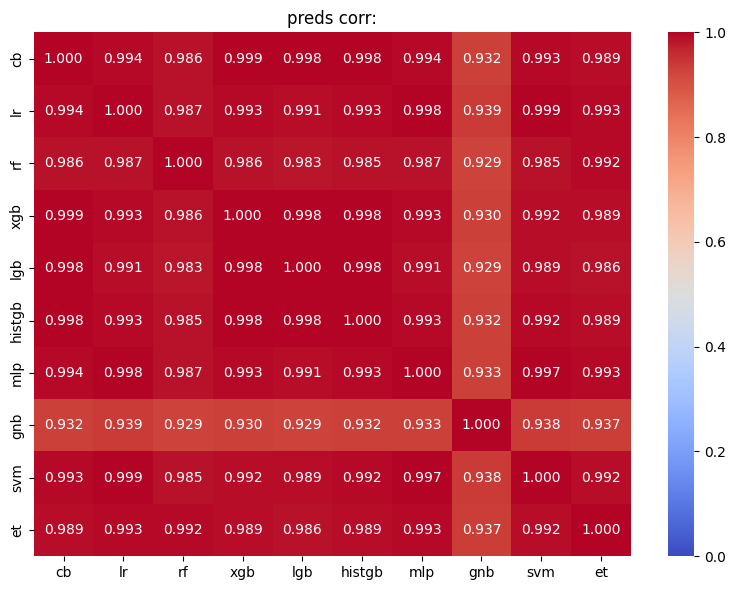

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.base import clone

cb_fe_2 = joblib.load('models/catboost_fe.pkl')
lr_fe = joblib.load('models/lr_fe.pkl')
rf_fe = joblib.load('models/rf_fe.pkl')
mlp_2 = joblib.load('models/mlp_2.pkl')
gnb = joblib.load('models/gnb.pkl')
et = joblib.load('models/et.pkl')
svm_cal = joblib.load('models/svm.pkl')
pr = {}

pr['cb'] = cb_fe_2.predict_proba(X_test)[:, 1]
pr['lr'] = lr_fe.predict_proba(X_test_lr)[:, 1]
pr['rf'] = rf_fe.predict_proba(X_test)[:, 1]
pr['xgb'] = xgb.predict_proba(X_test)[:, 1]
pr['lgb'] = lgb.predict_proba(X_test)[:, 1]
pr['histgb'] = histgb.predict_proba(X_test)[:, 1]
pr['mlp'] = mlp_2.predict_proba(X_test)[:, 1]
pr['gnb'] = gnb.predict_proba(X_test)[:, 1]
pr['svm'] = svm_cal.predict_proba(X_test)[:, 1]
pr['et'] = et.predict_proba(X_test)[:, 1]


pred_df = pd.DataFrame(pr)

for name, preds in predictions.items():
    print(name, roc_auc_score(y_val, preds))
    
corr_matrix = pred_df.corr(method='spearman')


plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', 
            center=0.5, vmin=0, vmax=1, fmt='.3f')
plt.title('preds corr:')
plt.tight_layout()
plt.show()

In [96]:
best_score = 0
best_weights = None


for w_cb in np.arange(0.2, 1.01, 0.05):
    for w_lgb in np.arange(0.2, 1.01 - w_cb, 0.05):
        for w_xgb in np.arange(0.2, 1.01 - w_cb - w_lgb, 0.05):
            for w_gnb in np.arange(0, 1.01 - w_cb - w_xgb - w_lgb, 0.02):
                w = 1 - w_cb - w_lgb - w_xgb - w_gnb
                if w < 0:
                    continue
                ensemble = (w_cb * pr['cb'] + 
                           w_lgb * pr['lgb'] + 
                           w_xgb * pr['xgb'] + 
                           w_gnb * pr['gnb'] + 
                           w * (pr['histgb'] + pr['mlp'] + 
                                    pr['rf'] + pr['lr'] + pr['et']) / 5)
                
                score = roc_auc_score(y_val, ensemble)
                
                if score > best_score:
                    best_score = score
                    best_weights = (w_cb, w_lgb, w_xgb, w_gnb, w)

print(f"w {best_weights}")
print(f'auc {best_score}')

subm['Heart Disease'] = (best_weights[0] * cb_fe_2.predict_proba(X_test)[:, 1] + 
                         best_weights[1] * lgb.predict_proba(X_test)[:, 1] + 
                         best_weights[2] * xgb.predict_proba(X_test)[:, 1] + 
                         best_weights[3] * gnb.predict_proba(X_test)[:, 1] + 
                         best_weights[4] * (histgb.predict_proba(X_test)[:, 1] + 
                                            rf_fe.predict_proba(X_test)[:, 1] + 
                                            lr_fe.predict_proba(X_test_lr)[:, 1] + 
                                            mlp_2.predict_proba(X_test)[:, 1] + 
                                            et.predict_proba(X_test)[:, 1]) / 5)
subm.to_csv('../data/subm/mean.csv', index=False)

w (np.float64(0.35), np.float64(0.44999999999999996), np.float64(0.2), np.float64(0.0), np.float64(5.551115123125783e-17))
auc 0.9552913267351164


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.7s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    3.3s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    5.3s finished


1) на валидации: 0.9551941147204536, перебор параметров не дал прироста
2) кагл 0.95337

In [20]:
pr_t = {}

pr_t['cb'] = cb_fe_2.predict_proba(X_test)[:, 1]
pr_t['lr'] = lr_fe.predict_proba(X_test_lr)[:, 1]
pr_t['rf'] = rf_fe.predict_proba(X_test)[:, 1]
pr_t['xgb'] = xgb.predict_proba(X_test)[:, 1]
pr_t['lgb'] = lgb.predict_proba(X_test)[:, 1]
pr_t['histgb'] = histgb.predict_proba(X_test)[:, 1]
pr_t['mlp'] = mlp_2.predict_proba(X_test)[:, 1]
pr_t['gnb'] = gnb.predict_proba(X_test)[:, 1]
pr_t['svm'] = svm_cal.predict_proba(X_test)[:, 1]
pr_t['et'] = et.predict_proba(X_test)[:, 1]

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    1.3s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    2.2s finished


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score, StratifiedKFold


X_meta = np.column_stack([pr['cb'], pr['lgb'], pr['xgb'], pr['histgb'],
    pr['mlp'], pr['rf'], pr['lr'], pr['et'], pr['gnb']])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_score = 0
best_model = None
best_name = ""

for C in [0.01, 0.1, 1.0, 10.0]:
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)
    scores = cross_val_score(model, X_meta, y_val, cv=cv, scoring='roc_auc')
    print(f"LR C={C}: {scores.mean()}")
    if scores.mean() > best_score:
        best_score, best_model, best_name = scores.mean(), model, f"LR_C={C}"

for n_est in [50, 100]:
    for depth in [3, 5, None]:
        model = RandomForestClassifier(n_estimators=n_est, max_depth=depth, random_state=42, n_jobs=-1)
        scores = cross_val_score(model, X_meta, y_val, cv=cv, scoring='roc_auc')
        print(f"rf n={n_est} depth={depth}: {scores.mean()}")
        if scores.mean() > best_score:
            best_score, best_model, best_name = scores.mean(), model, f"RF_{n_est}_{depth}"

for alpha in [0.1, 1.0, 10.0]:
    ridge = RidgeClassifier(alpha=alpha, random_state=42)
    model = CalibratedClassifierCV(ridge, cv=3)
    scores = cross_val_score(model, X_meta, y_val, cv=cv, scoring='roc_auc')
    print(f"Ridge alpha={alpha}: {scores.mean()}")
    if scores.mean() > best_score:
        best_score, best_model, best_name = scores.mean(), model, f"Ridge_{alpha}"


print({best_name},  {best_score})
joblib.dump(best_model, 'models/meta.pkl')
best_model.fit(X_meta, y_val)

LR C=0.01: 0.9548385669326684
LR C=0.1: 0.9550881163092825
LR C=1.0: 0.955100674883156
LR C=10.0: 0.9550718026083601
rf n=50 depth=3: 0.9536341351765987
rf n=50 depth=5: 0.9551926714713488
rf n=50 depth=None: 0.949302159753786
rf n=100 depth=3: 0.9537176304995979
rf n=100 depth=5: 0.9551989356534849
rf n=100 depth=None: 0.9507299893732151
Ridge alpha=0.1: 0.9553072711126088
Ridge alpha=1.0: 0.9553086886138555
Ridge alpha=10.0: 0.9553033586841467
{'Ridge_1.0'} {np.float64(0.9553086886138555)}


,estimator,RidgeClassifi...ndom_state=42)
,method,'sigmoid'
,cv,3
,n_jobs,None
,ensemble,'auto'
,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,class_weight,None


In [22]:
from itertools import combinations
from sklearn.model_selection import cross_val_score

best_meta = joblib.load('models/meta.pkl')

X_meta = np.column_stack([pr['cb'], pr['lgb'], pr['xgb'], pr['histgb'],
    pr['mlp'], pr['rf'], pr['lr'], pr['et'], pr['gnb']])

model_names = ['cb','lgb','xgb','histgb','mlp','rf','lr','et','gnb']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_score = 0
best_combo = None

for k in range(3, 10):
    for combo in combinations(range(9), k):
        X_subset = X_meta[:, combo]
        scores = cross_val_score(best_meta, X_subset, y_val, cv=cv, scoring='roc_auc')
        mean_score = scores.mean()
        
        if mean_score > best_score:
            best_score = mean_score
            best_combo = combo
            print(f"{[model_names[i] for i in combo]}: {mean_score:.6f}")

print(f"models: {[model_names[i] for i in best_combo]}")
print(f"auc {best_score:.6f}")

['cb', 'lgb', 'xgb']: 0.955279
['cb', 'lgb', 'histgb']: 0.955286
['cb', 'lgb', 'mlp']: 0.955295
['cb', 'lgb', 'lr']: 0.955310
['cb', 'lgb', 'histgb', 'lr']: 0.955312
['cb', 'lgb', 'rf', 'lr']: 0.955314
['cb', 'lgb', 'xgb', 'rf', 'lr']: 0.955317
['cb', 'lgb', 'xgb', 'histgb', 'rf', 'lr']: 0.955317
['cb', 'lgb', 'xgb', 'rf', 'lr', 'et']: 0.955317
['cb', 'lgb', 'xgb', 'histgb', 'rf', 'lr', 'et']: 0.955319
models: ['cb', 'lgb', 'xgb', 'histgb', 'rf', 'lr', 'et']
auc 0.955319


In [52]:
selected_models = ['cb', 'lgb', 'xgb', 'histgb', 'rf', 'lr', 'et']

X_meta_7 = X_meta[:, list(best_combo)]
meta = CalibratedClassifierCV(RidgeClassifier(alpha= 1.0, random_state=42), cv= 5)
meta.fit(X_meta_7, y_val)
joblib.dump(meta, 'meta_7.pkl')

test_preds_list = []
for model_name in selected_models:
    if model_name == 'cb':
        preds = cb_fe_2.predict_proba(X_test)[:, 1]
    elif model_name == 'lgb':
        preds = lgb.predict_proba(X_test)[:, 1]
    elif model_name == 'xgb':
        preds = xgb.predict_proba(X_test)[:, 1]
    elif model_name == 'histgb':
        preds = histgb.predict_proba(X_test)[:, 1]
    elif model_name == 'rf':
        preds = rf_fe.predict_proba(X_test)[:, 1]
    elif model_name == 'lr':
        preds = lr_fe.predict_proba(X_test_lr)[:, 1]
    elif model_name == 'et':
        preds = et.predict_proba(X_test)[:, 1]
    
    test_preds_list.append(preds)

X_test_m = np.column_stack(test_preds_list)

p = meta.predict_proba(X_test_m)[:, 1]

subm['Heart Disease'] = p
subm.to_csv('../data/subm/st_3_0.csv', index=False)


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.7s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    3.7s
[Parallel(n_jobs=4)]: Done 300 out of 300 | elapsed:    5.4s finished


кагл 0.95346